<a href="https://colab.research.google.com/github/RobJavVar/DataSciencePsychNeuro/blob/master/ExerciseSubmissions/16_selecting-the-best-model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 16: Model selection

This homework is designed to give you practice implementing model selection techniques, including best subset selection and forward/backward stepwise selection.

You won't need to load in any data for this homework, we will be simulating our own.

---
## 1. Best subset selection (4 points)

In this question, we will first generate simulated data, and then use it to perform best subset selection.

a) Use `rnorm()` to generate a dataset including a predictor $X$ of length $n = 100$ and a noise vector $\epsilon$ of length $n = 100$. Generate data for a response variable $Y$ of length $n = 100$ according to the model

$Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon$

where $\beta_0$, $\beta_1$, $\beta_2$, and $\beta_3$ are constants of your choice.


In [1]:
# WRITE YOUR CODE HERE
set.seed(15)

n <- 100
X <- rnorm(n)
e <- rnorm(n)

beta0 <- 1
beta1 <- 2
beta2 <- 3
beta3 <- 4

Y <- beta0 + beta1*X + beta2*X^2 + beta3*X^3 + e


b) Use `regsubsets()` to perform best subset selection to determine the best model that contains the predictor variables $X$, $X^2$, . . . , $X^{10}$. Print the model summary.

In [4]:
# WRITE YOUR CODE HERE
install.packages("leaps")   
library(leaps)

X_all <- data.frame(X)

for (i in 2:10) {
  X_all[[paste0("X", i)]] <- X^i}

df <- data.frame(Y, X_all)

model <- regsubsets(Y~ ., data=df, nvmax= 10)

summary <- summary(model)
summary


The downloaded binary packages are in
	/var/folders/xn/6zv05bqd6pg_55q7h9xf15h00000gn/T//Rtmpl3kuhz/downloaded_packages


Subset selection object
Call: regsubsets.formula(Y ~ ., data = df, nvmax = 10)
10 Variables  (and intercept)
    Forced in Forced out
X       FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: exhaustive
          X   X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  " " " " "*" " " " " " " " " " " " " " "
2  ( 1 )  " " "*" "*" " " " " " " " " " " " " " "
3  ( 1 )  "*" "*" "*" " " " " " " " " " " " " " "
4  ( 1 )  "*" "*" "*" " " " " "*" " " " " " " " "
5  ( 1 )  "*" "*" "*" " " "*" "*" " " " " " " " "
6  ( 1 )  "*" " " "*" "*" " " "*" " " "*" " " "*"
7  ( 1 )  "*" "*" "*" "*" " " "*" " " "*" " " "*"
8  ( 1 )  "*" "*" "*" "*" "*" "*" " " "*" " " "*"
9  ( 1 )  "*" "*" "*" "*" " " "*" "*" "*" "*" "*"
10  ( 1 ) "*" "*" "*" "*" "*" "*" "*" "*" "*" "*"

In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

c) Plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Which is the best model? Report the coefficients of the best model.

[1] 7

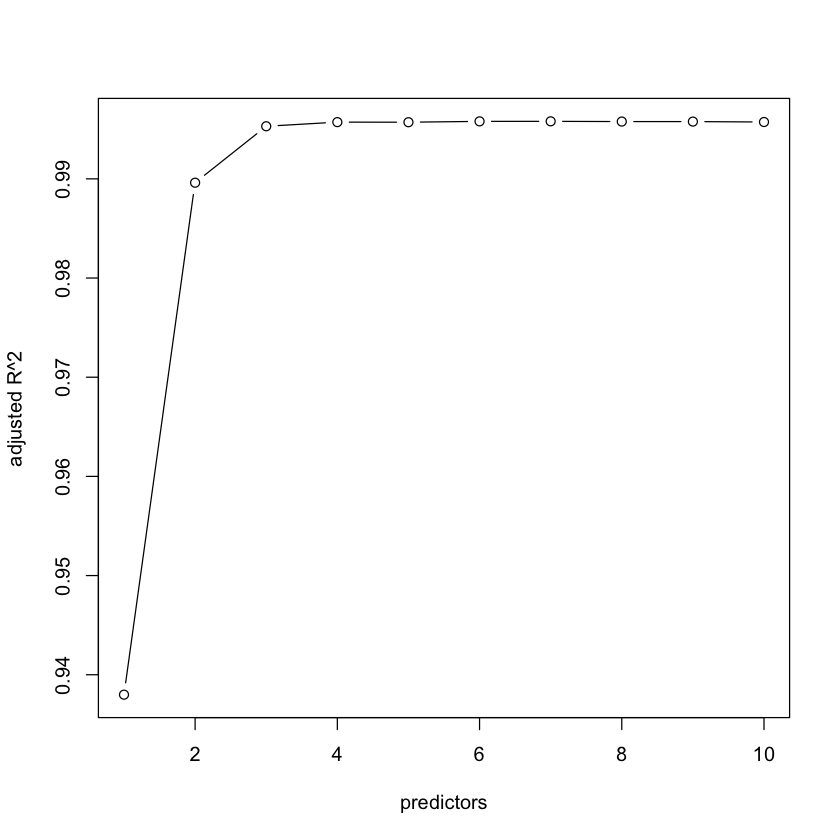

[1] 4

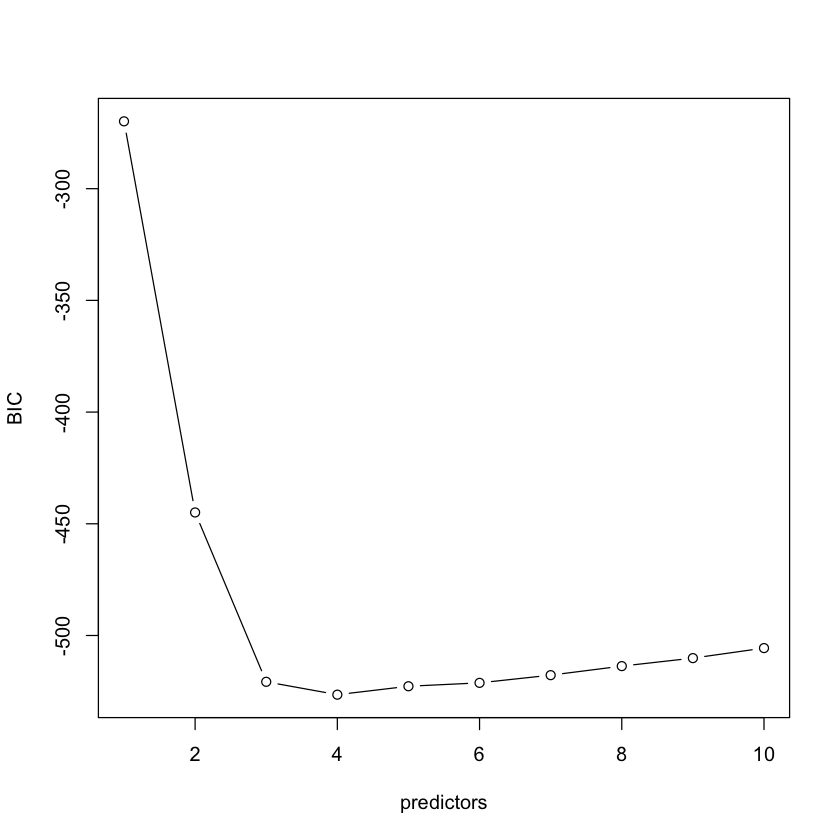

[1] 4

(Intercept)           X          X2          X3          X6 
 0.56961161  2.03196689  3.50086631  3.99080549 -0.01730072

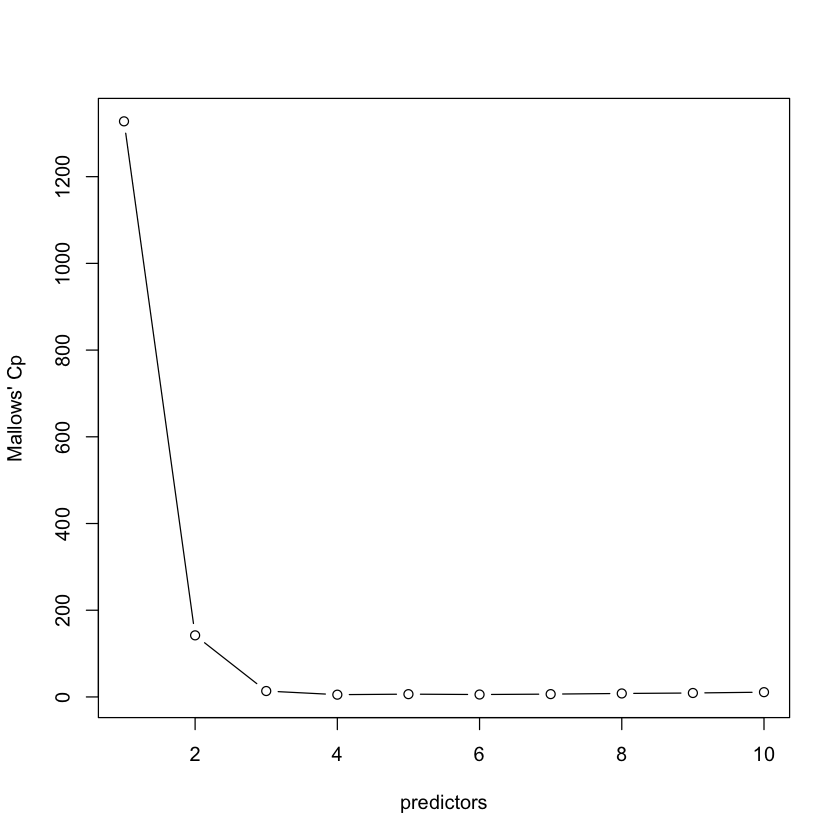

In [8]:
# WRITE YOUR CODE HERE

plot(summary$adjr2, type="b", xlab="predictors", ylab="adjusted R^2")
which.max(summary$adjr2) 

plot(summary$bic, type="b", xlab="predictors", ylab="BIC")
which.min(summary$bic) 

plot(summary$cp, type="b", xlab="predictors", ylab="Mallows' Cp")
which.min(summary$cp)

model_best <- coef(model, 4)  
model_best

> *Write your response here*
>BIC and Mallow's suggests the best model has four predictors, while R^2 suggests 7. I would choose the model with 4 predictors since it is simpler and will therfore generalize better.
> Y=0.57 + 2.03X1 + 3.50X2 + 3.99X3 - 0.02X6

---
## 2. Forward and backwards stepwise selection (3 points)

Using the same simulated data from question 1, use forward stepwise selection, and backwards stepwise selections to determine the best model. Again, for both model selection methods, plot the Mallows' Cp, Bayesian Information Criteria (BIC) and the adjusted coefficient of determination, $R^2$, for each model tested. Report the coefficients of the best model.

a) Forward stepwise selection:

Subset selection object
Call: regsubsets.formula(Y ~ ., data = df, nvmax = 10, method = "forward")
10 Variables  (and intercept)
    Forced in Forced out
X       FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: forward
          X   X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  " " " " "*" " " " " " " " " " " " " " "
2  ( 1 )  " " "*" "*" " " " " " " " " " " " " " "
3  ( 1 )  "*" "*" "*" " " " " " " " " " " " " " "
4  ( 1 )  "*" "*" "*" " " " " "*" " " " " " " " "
5  ( 1 )  "*" "*" "*" " " "*" "*" " " " " " " " "
6  ( 1 )  "*" "*" "*" " " "*" "*" "*" " " " " " "
7  ( 1 )  "*" "*" "*" " " "*" "*" "*" " " "*" " "
8  ( 1 )  "*" "*" "*" " " "*" "*" "*" "*" "*" " "
9  ( 1 )  "*" "*" "*" "*" "*" "*" "*" "*" "*" " "
10  ( 1 ) "*" "*" "*" "*" "*" "*" "

[1] 10

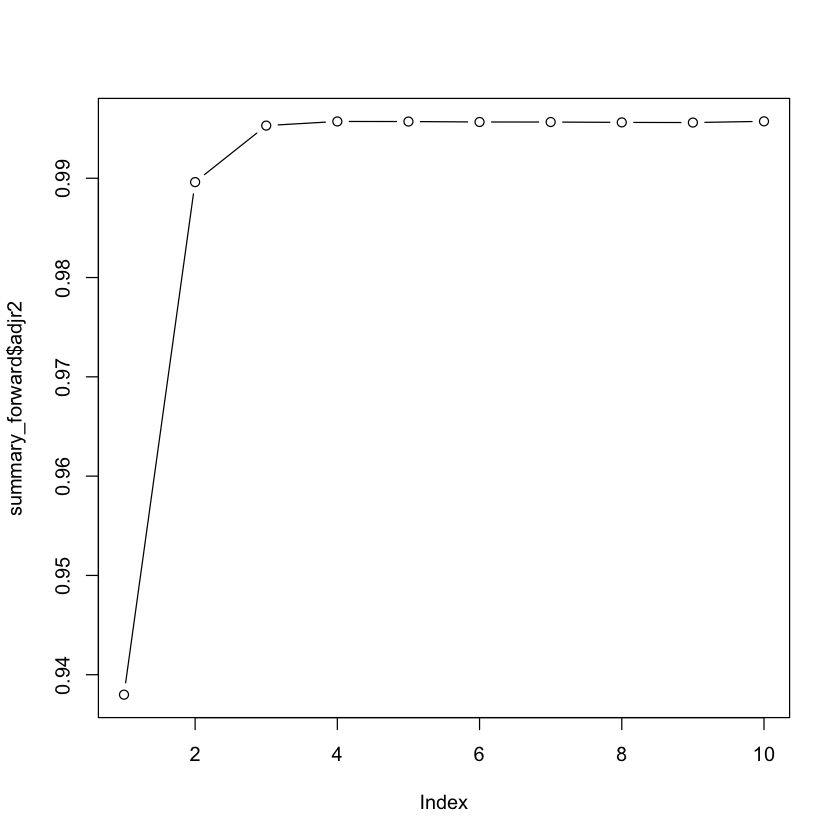

[1] 4

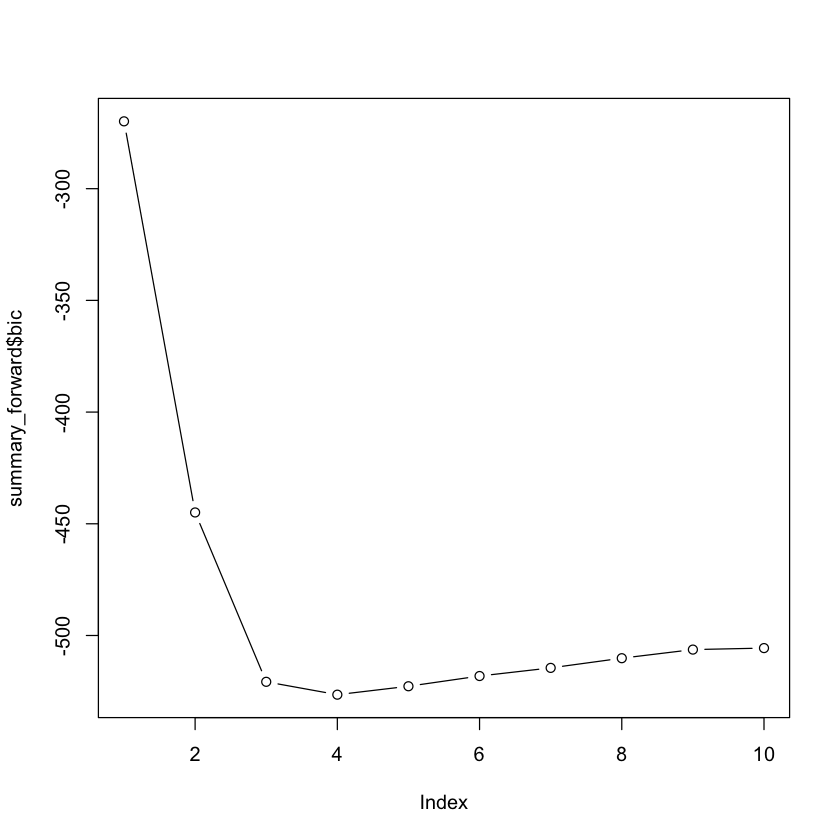

[1] 4

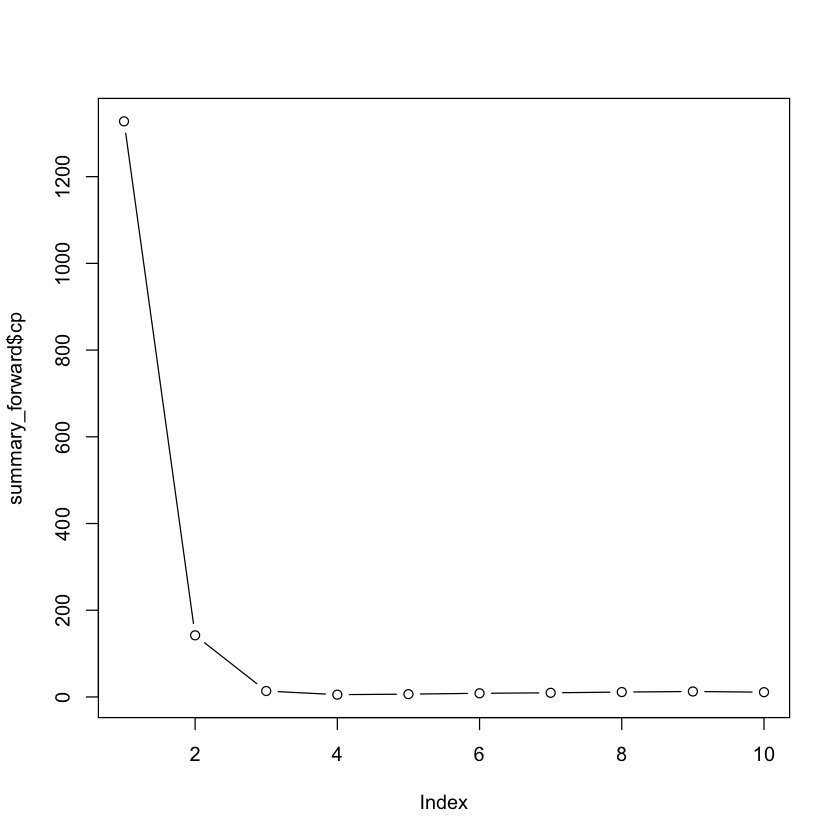

In [17]:
# WRITE YOUR CODE HERE

model_forward <- regsubsets(Y ~ ., data=df, nvmax=10, method="forward")
summary_forward <- summary(model_forward)
summary_forward

plot(summary_forward$adjr2, type="b")
which.max(summary_forward$adjr2) 

plot(summary_forward$bic, type="b")
which.min(summary_forward$bic) 

plot(summary_forward$cp, type="b")
which.min(summary_forward$cp) 




In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

b) Backwards stepwise selection:

Subset selection object
Call: regsubsets.formula(Y ~ ., data = df, nvmax = 10, method = "backward")
10 Variables  (and intercept)
    Forced in Forced out
X       FALSE      FALSE
X2      FALSE      FALSE
X3      FALSE      FALSE
X4      FALSE      FALSE
X5      FALSE      FALSE
X6      FALSE      FALSE
X7      FALSE      FALSE
X8      FALSE      FALSE
X9      FALSE      FALSE
X10     FALSE      FALSE
1 subsets of each size up to 10
Selection Algorithm: backward
          X   X2  X3  X4  X5  X6  X7  X8  X9  X10
1  ( 1 )  " " " " "*" " " " " " " " " " " " " " "
2  ( 1 )  " " " " "*" "*" " " " " " " " " " " " "
3  ( 1 )  " " " " "*" "*" " " "*" " " " " " " " "
4  ( 1 )  "*" " " "*" "*" " " "*" " " " " " " " "
5  ( 1 )  "*" " " "*" "*" " " "*" " " "*" " " " "
6  ( 1 )  "*" " " "*" "*" " " "*" " " "*" " " "*"
7  ( 1 )  "*" " " "*" "*" " " "*" "*" "*" " " "*"
8  ( 1 )  "*" " " "*" "*" " " "*" "*" "*" "*" "*"
9  ( 1 )  "*" "*" "*" "*" " " "*" "*" "*" "*" "*"
10  ( 1 ) "*" "*" "*" "*" "*" "*"

[1] 6

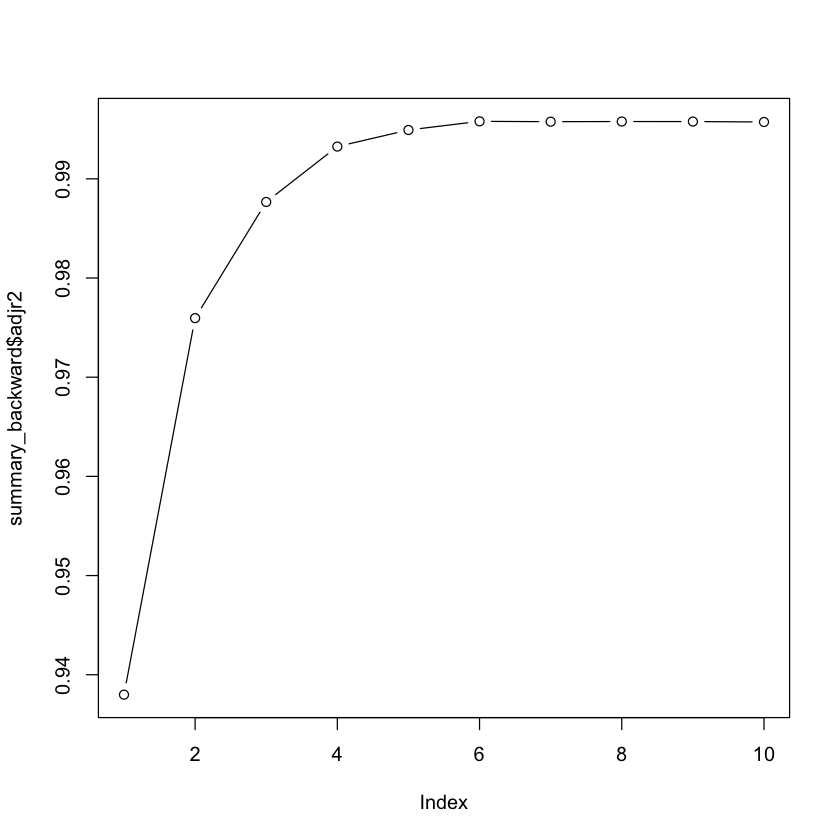

[1] 6

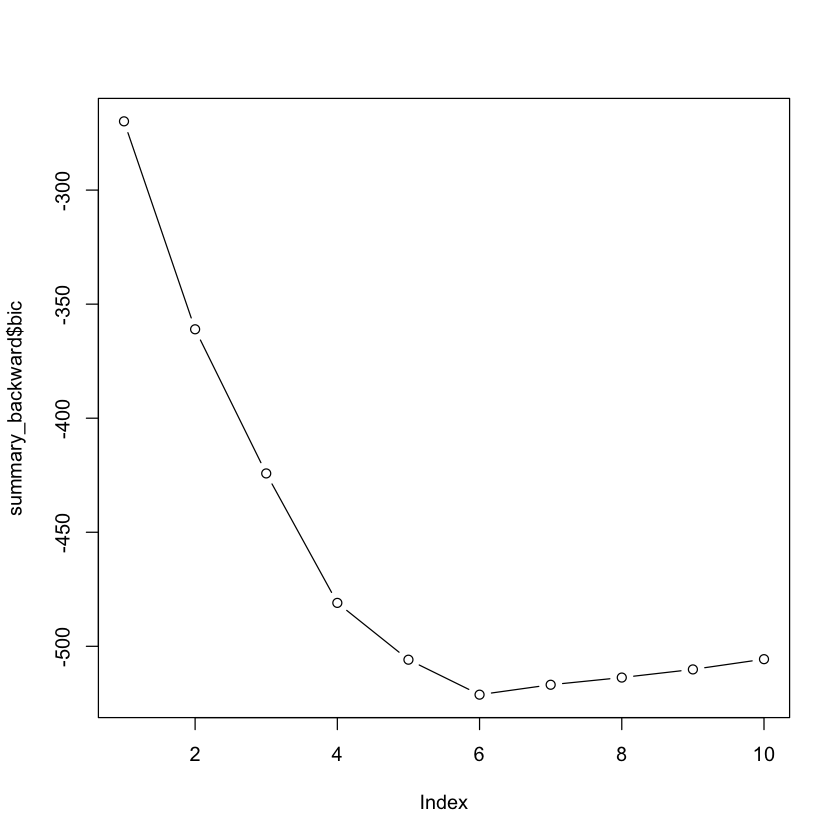

[1] 6

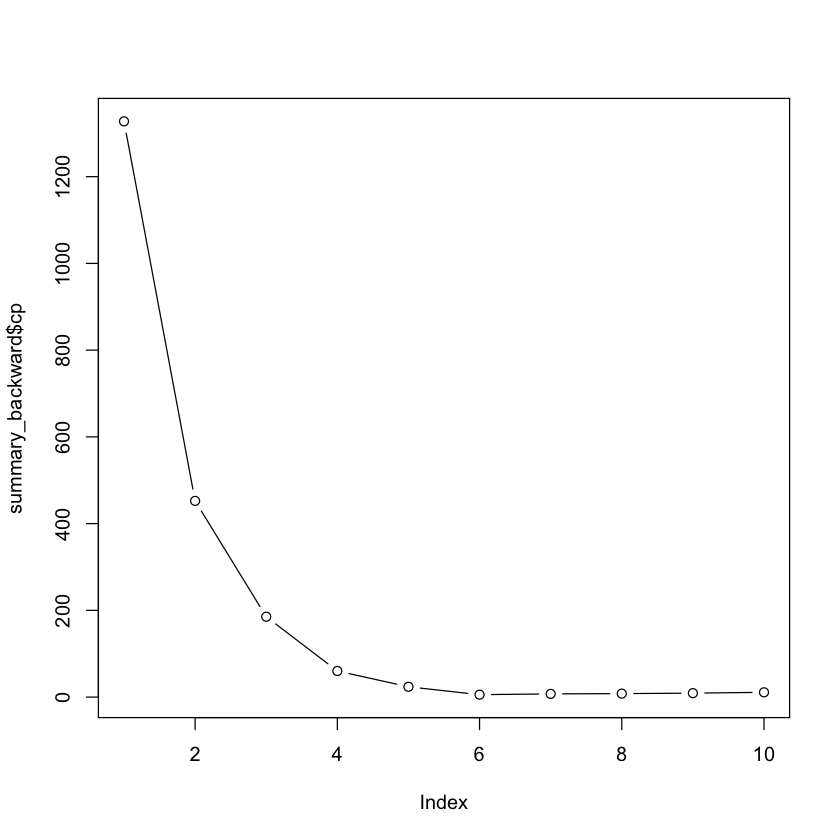

In [18]:
# WRITE YOUR CODE HERE
model_backward <- regsubsets(Y ~ ., data=df, nvmax=10, method="backward")
summary_backward <- summary(model_backward)
summary_backward

plot(summary_backward$adjr2, type="b")
which.max(summary_backward$adjr2) 

plot(summary_backward$bic, type="b")
which.min(summary_backward$bic) 

plot(summary_backward$cp, type="b")
which.min(summary_backward$cp) 


In [ ]:
# Note: if your model summary doesn't show up when viewing your notebook on github, copy and paste the output below.
# Otherwise you can either delete this cell or leave it blank.

```
# paste here

```

c) Compare your results from parts a and b with those of question 1.

> *Write your response here*
>Forward and backward stepwise results differed somewhat from best subset selection. Both best subset and forward identified 4 predictors as optimal based on BIC and Mallow's, suggesting that forward selecction better approximated the best model. Backward chose 6 predictors, which may reflect the method of elimination. My takeaway is that stepwise methods can lead to different results and may not always identify the most parsimonious model compared to best subset selection

---
## 3. Training and test error (3 points)

This question will explore the relationship between training and test error and the number of features included in a model. We will again use a simulated dataset.

a) Simulate dataset with features $p = 20$ and observations $n = 1,000$. Generate data for a response variable $Y$ according to the model

$Y = X\beta + \epsilon$

where $\beta$ is random with some elements that are exactly zero.

Split your simulated dataset into a training set containing $n=100$ observations and a test set containing $n=900$ observations.

In [23]:
# WRITE YOUR CODE HERE
set.seed(15)

n <- 1000
p <- 20

X <- matrix(rnorm(n*p), nrow=n, ncol=p)

beta <- rnorm(p)
beta[c(1, 2, 5, 7)] <- c(3, 1.5, 2, 4)  

zero <- sample(1:p, 4)
beta[zero] <- 0

e <- rnorm(n)

Y <- X%*%beta + e

# train/test  
train <- sample(1:n, 100)  
X_train <- X[train, ]
Y_train <- Y[train]

X_test <- X[-train, ]
Y_test <- Y[-train]

train <- data.frame(Y = Y_train, X_train)
test <- data.frame(Y = Y_test, X_test)

b) Perform best subset selection on the training set, and plot the associated training and test set MSE for the best model of each size.

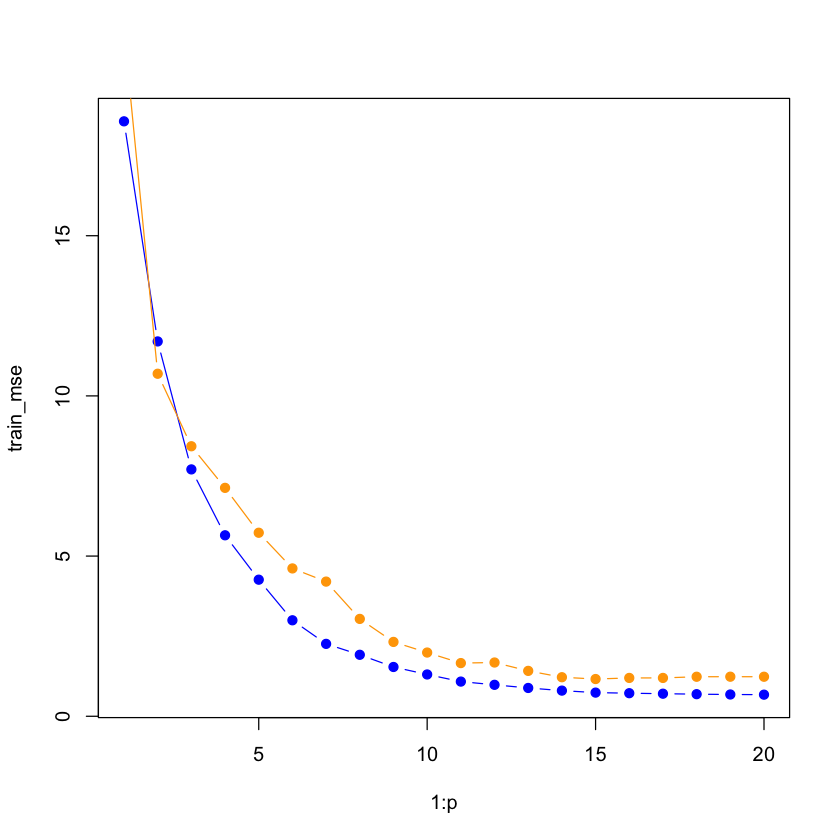

In [30]:
# WRITE YOUR CODE HERE
p <- ncol(X_train) 
train_mse <- rep(NA, p)
test_mse  <- rep(NA, p)

for (i in 1:p) {
  coef_i <- coef(model_best, i)
  pred_train <- as.matrix(cbind(1, train[, names(coef_i)[-1]]))%*%coef_i
  train_mse[i] <- mean((train$Y-pred_train)^2)
  
  pred_test <- as.matrix(cbind(1, test[, names(coef_i)[-1]]))%*%coef_i
  test_mse[i] <- mean((test$Y-pred_test)^2)}

# Minimal plot
plot(1:p, train_mse, type ="b", col = "blue", pch = 19)
lines(1:p, test_mse, type = "b", col = "orange", pch= 19)


c) Identify the best model according the test MSE. How does this model compare to the actual model used to simulate the dataset?

*Note: If the model identified contains only an intercept or all of the features, then generate a new dataset (i.e. repeat part a with a different random seed) until the test set MSE is minimized for an intermediate model size.*

In [34]:
# WRITE YOUR CODE HERE
best <- which.min(test_mse)
best

coef <- coef(model_best, best)
coef

beta


[1] 15

(Intercept)          X1          X2          X3          X4          X6 
 0.01250801  2.95320950  1.39333546 -0.23121825 -0.32578175  1.32129148 
         X8          X9         X11         X12         X13         X14 
 0.67798828 -0.34348371 -1.19844307 -0.34168269 -0.61193102 -1.29590754 
        X15         X16         X17         X18 
-3.42820493  0.69572853 -0.90058944  0.51745016

[1]  3.0000000  1.5000000 -0.2359899 -0.4296264  0.0000000  1.2601759
 [7]  0.0000000  0.6106589 -0.4410078  0.0000000 -1.0862850 -0.1648323
[13] -0.5232500 -1.2631482 -3.3505777  0.6927018 -1.0119864  0.5862633
[19] -0.1565596  0.0000000

> *Write your response here*
>The best model according to test MSE included 15 predictors and had a test MSE of 15. It approximately captured the predictors with the largest simulated effects (like X1 and X2) but also included predictors with very small effects and missed some other non-zero coefficients. This might be because the training sample is so small.

**DUE:** 5pm EST, April 2, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*